# Multiple Linear Regression — House Price Prediction (Pakistan)

**Dataset:** This dataset contains information about houses in Pakistan. It includes features such as `city`, `area`, `bedrooms`, `bathrooms`, `house_age`, `distance_from_city_center`, `parking`, `gas`, `furnished`, `property_type`, and the target variable `price_lakh_pkr` (house price in lakhs of Pakistani Rupees).

**Description:** Multiple Linear Regression uses **more than one input feature** (X1, X2, X3, ...) to predict **one output** (Y). In this dataset, the house price does not depend on only one feature. It depends on **city, area, number of bedrooms, bathrooms, house age, distance from the city center, property type, and available amenities**. Because many features affect the house price, this dataset is a good example of Multiple Linear Regression.

**Formula:** `price = b0 + b1*X1 + b2*X2 + ... + bn*Xn`


## 1. Libraries aur Dataset Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

df = pd.read_csv('pakistan_house_prices.csv')
df.head()

,city,property_type,area_marla,bedrooms,bathrooms,age_years,distance_from_city_center_km,has_parking,has_gas,is_furnished,price_lakh_pkr
0,Karachi,House,17.8,7,6,1,0.6,1,1,1,432.5
1,Bannu,House,15.2,5,4,6,1.0,1,1,1,157.6
2,Peshawar,House,18.8,8,5,3,4.3,1,0,0,353.9
3,Rawalpindi,Upper Portion,13.4,3,3,4,15.3,0,1,0,110.7
4,Lahore,Flat,10.6,4,4,32,11.8,0,1,0,98.0


In [3]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   city                          3000 non-null   str    
 1   property_type                 3000 non-null   str    
 2   area_marla                    3000 non-null   float64
 3   bedrooms                      3000 non-null   int64  
 4   bathrooms                     3000 non-null   int64  
 5   age_years                     3000 non-null   int64  
 6   distance_from_city_center_km  3000 non-null   float64
 7   has_parking                   3000 non-null   int64  
 8   has_gas                       3000 non-null   int64  
 9   is_furnished                  3000 non-null   int64  
 10  price_lakh_pkr                3000 non-null   float64
dtypes: float64(3), int64(6), str(2)
memory usage: 257.9 KB


,city,property_type,area_marla,bedrooms,bathrooms,age_years,distance_from_city_center_km,has_parking,has_gas,is_furnished,price_lakh_pkr
count,3000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
unique,8,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Karachi,House,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,522,1634,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,12.869900,4.002000,3.214000,8.208667,6.276700,0.757667,0.838000,0.306667,182.376967
std,NaN,NaN,4.669161,1.582876,1.366319,8.094173,6.111831,0.428566,0.368512,0.461187,113.285267
min,NaN,NaN,3.600000,1.000000,1.000000,0.000000,0.200000,0.000000,0.000000,0.000000,20.300000
25%,NaN,NaN,9.500000,3.000000,2.000000,3.000000,1.800000,1.000000,1.000000,0.000000,102.900000
50%,NaN,NaN,12.100000,4.000000,3.000000,6.000000,4.400000,1.000000,1.000000,0.000000,154.150000
75%,NaN,NaN,15.525000,5.000000,4.000000,11.000000,8.700000,1.000000,1.000000,1.000000,232.925000


## 2. Selecting Features and Encoding Categorical Data

We first select the input features for the model. Then, we convert the categorical columns (`city` and `property_type`) into numerical values using **One-Hot Encoding**, because a Linear Regression model cannot work with text data. This process creates separate binary (0 or 1) columns for each category, allowing the model to use them for prediction.


In [4]:
feature_cols = ['area_marla', 'bedrooms', 'bathrooms', 'age_years',
                 'distance_from_city_center_km', 'has_parking', 'has_gas',
                 'is_furnished', 'city', 'property_type']

X = df[feature_cols]
y = df['price_lakh_pkr']

cat_cols = ['city', 'property_type']
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

## 3. Train-Test Split aur Model Training

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline(steps=[('prep', preprocessor), ('model', LinearRegression())])
pipe.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## 4. Model Evaluation

In [6]:
preds = pipe.predict(X_test)

print(f"R2 Score : {r2_score(y_test, preds):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, preds):.2f} lakh PKR")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, preds)):.2f} lakh PKR")

R2 Score : 0.8538
MAE      : 29.72 lakh PKR
RMSE     : 41.25 lakh PKR


## 5. Feature Importance (Coefficients)

In [7]:
model = pipe.named_steps['model']
prep = pipe.named_steps['prep']
cat_feature_names = list(prep.named_transformers_['cat'].get_feature_names_out(cat_cols))
all_feature_names = cat_feature_names + num_cols

coef_df = pd.DataFrame({'feature': all_feature_names, 'coefficient': model.coef_})
coef_df = coef_df.sort_values('coefficient', ascending=False)

print("Price BARHANE wale top factors:")
print(coef_df.head(5).to_string(index=False))
print("\nPrice GHATANE wale top factors:")
print(coef_df.tail(5).to_string(index=False))

Price BARHANE wale top factors:
            feature  coefficient
     city_Islamabad    75.881646
property_type_House    57.442536
       city_Karachi    57.307885
        city_Lahore    44.171476
         area_marla    14.201100

Price GHATANE wale top factors:
                    feature  coefficient
              city_Peshawar   -31.453477
property_type_Lower Portion   -35.280956
            city_Faisalabad   -37.427242
                city_Multan   -44.154268
                 city_Bannu   -73.401096


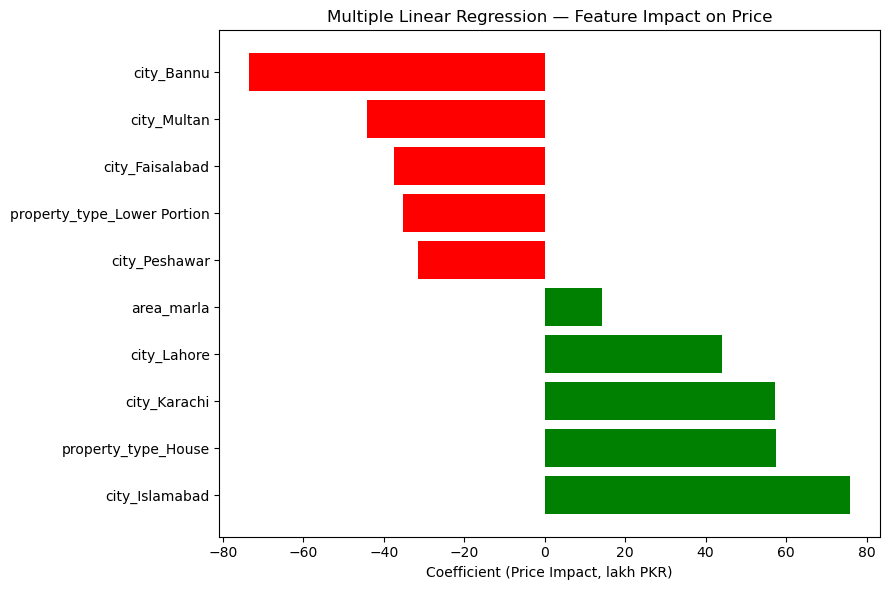

In [8]:
plt.figure(figsize=(9,6))
top_features = pd.concat([coef_df.head(5), coef_df.tail(5)])
colors = ['green' if c > 0 else 'red' for c in top_features['coefficient']]
plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.xlabel('Coefficient (Price Impact, lakh PKR)')
plt.title('Multiple Linear Regression — Feature Impact on Price')
plt.tight_layout()
plt.show()

## 6. Actual vs Predicted Visualization

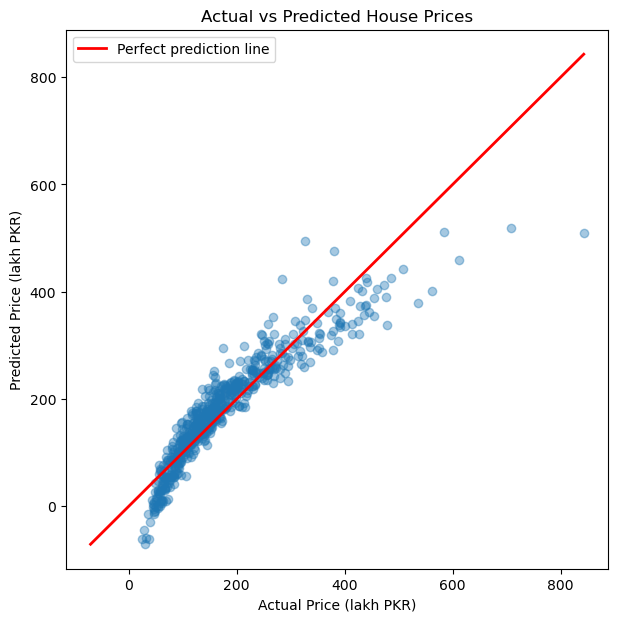

In [9]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, preds, alpha=0.4)
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims, color='red', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual Price (lakh PKR)')
plt.ylabel('Predicted Price (lakh PKR)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.show()

## 7. New Value Prediction

Ek naye ghar ki details dekar price predict karte hain.

In [10]:
new_house = pd.DataFrame({
    'area_marla': [10],
    'bedrooms': [3],
    'bathrooms': [2],
    'age_years': [5],
    'distance_from_city_center_km': [4],
    'has_parking': [1],
    'has_gas': [1],
    'is_furnished': [0],
    'city': ['Islamabad'],
    'property_type': ['House']
})

predicted_price = pipe.predict(new_house)
print(f"10 Marla, Islamabad, 3-bed House ki predicted price: {predicted_price[0]:.2f} lakh PKR")

# Same house in different cities for comparison
for city in ['Islamabad', 'Lahore', 'Karachi', 'Bannu', 'Peshawar']:
    h = new_house.copy()
    h['city'] = city
    p = pipe.predict(h)[0]
    print(f"City = {city:<12} -> Predicted Price = {p:.2f} lakh PKR")

10 Marla, Islamabad, 3-bed House ki predicted price: 236.26 lakh PKR
City = Islamabad    -> Predicted Price = 236.26 lakh PKR
City = Lahore       -> Predicted Price = 204.55 lakh PKR
City = Karachi      -> Predicted Price = 217.68 lakh PKR
City = Bannu        -> Predicted Price = 86.97 lakh PKR
City = Peshawar     -> Predicted Price = 128.92 lakh PKR


## 8. Summary

* Multiple Linear Regression used **10 input features** to predict the house price, which gives **better accuracy** than Simple Linear Regression.
* **Location (city)** is one of the most important factors in the Pakistan real estate market. Houses in cities like **Islamabad, Karachi, and Lahore** usually have higher prices, while houses in smaller cities such as **Bannu** are generally less expensive.
* This approach is **more realistic** for real-world house price prediction because it considers **multiple factors at the same time**, instead of relying on only one feature.
